In [24]:
# Imports
import os
from pathlib import Path
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

if hasattr(torch, "xpu") and torch.xpu.is_available():
    DEVICE = torch.device("xpu")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

Using device: xpu


In [25]:
# Seed
def set_seed(seed=42): # setting the seed makes the random functions like splitting datasets more reproducible
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [26]:
HOME_DIR = Path.home()
DATA_DIR = HOME_DIR / "OneDrive - National University of Singapore" / "Documents" / "NUS Self-learning" / "CG4002" / "archive" / "HAR-for-human-robot-interaction-in-agriculture" / "Human-activity-recognition-for-human-robot-interaction-in-agriculture" / "Raw_data"

FEATURE_COLS = [
    "ax_m/s/s", "ay_m/s/s", "az_m/s/s",
    "gx_deg/s", "gy_deg/s", "gz_deg/s",
    "mx_microT", "my_microT", "mz_microT"
]

LABEL_COL = "condition"

CLASS_NAMES = {
    0: "Standing",
    1: "Walking (without crate)",
    2: "Bending",
    3: "Lifting crate",
    4: "Walking (with crate)",
    5: "Placing crate"
}

NUM_CLASSES = 6

WINDOW_SIZE = 50
STRIDE = 25
PURITY_THRESHOLD = 0.8

BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VAL_SIZE = 0.15
TEST_SIZE = 0.15

In [27]:
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

print("Path exists:", os.path.exists(DATA_DIR))
print("Number of CSV files found:", len(all_files))
print("First 5 files:")
for f in all_files[:5]:
    print(f)


Path exists: True
Number of CSV files found: 930
First 5 files:
C:\Users\user\OneDrive - National University of Singapore\Documents\NUS Self-learning\CG4002\archive\HAR-for-human-robot-interaction-in-agriculture\Human-activity-recognition-for-human-robot-interaction-in-agriculture\Raw_data\A001_1530.csv
C:\Users\user\OneDrive - National University of Singapore\Documents\NUS Self-learning\CG4002\archive\HAR-for-human-robot-interaction-in-agriculture\Human-activity-recognition-for-human-robot-interaction-in-agriculture\Raw_data\A001_1561.csv
C:\Users\user\OneDrive - National University of Singapore\Documents\NUS Self-learning\CG4002\archive\HAR-for-human-robot-interaction-in-agriculture\Human-activity-recognition-for-human-robot-interaction-in-agriculture\Raw_data\A001_1567.csv
C:\Users\user\OneDrive - National University of Singapore\Documents\NUS Self-learning\CG4002\archive\HAR-for-human-robot-interaction-in-agriculture\Human-activity-recognition-for-human-robot-interaction-in-agricul

In [28]:
train_files, temp_files = train_test_split(
    all_files,
    test_size=(VAL_SIZE + TEST_SIZE),
    random_state=42,
    shuffle=True
)

relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)

val_files, test_files = train_test_split(
    temp_files,
    test_size=relative_test_size,
    random_state=42,
    shuffle=True
)

print(f"Train files: {len(train_files)}")
print(f"Val files:   {len(val_files)}")
print(f"Test files:  {len(test_files)}")

import pandas as pd

# Assuming `test_files` contains the list of test CSV file paths
test_files_df = pd.DataFrame({'test_file_path': test_files})
test_files_df.to_csv('cg4002_selected_test_files.csv', index=False)

print(
    f'Saved {len(test_files)} test file paths to'
    " 'cg4002_selected_test_files.csv'"
)


Train files: 651
Val files:   139
Test files:  140
Saved 140 test file paths to 'cg4002_selected_test_files.csv'


In [29]:
def create_windows_from_file(filepath, feature_cols, label_col,
                             window_size=50, stride=25, purity_threshold=0.8):
    df = pd.read_csv(filepath)
    df = df.dropna().reset_index(drop=True)
    df[label_col] = df[label_col].astype(int)

    X = df[feature_cols].values.astype(np.float32)
    y = df[label_col].values.astype(np.int64)

    windows = []
    labels = []

    if len(df) < window_size:
        return windows, labels

    for start in range(0, len(df) - window_size + 1, stride):
        end = start + window_size

        x_win = X[start:end]
        y_win = y[start:end]

        counts = np.bincount(y_win, minlength=NUM_CLASSES)
        majority_label = counts.argmax()
        purity = counts[majority_label] / window_size

        if purity >= purity_threshold:
            windows.append(x_win)
            labels.append(majority_label)

    return windows, labels

def load_windows_from_files(file_list, feature_cols, label_col,
                            window_size=50, stride=25, purity_threshold=0.8):
    X_all = []
    y_all = []

    for filepath in tqdm(file_list):
        windows, labels = create_windows_from_file(
            filepath=filepath,
            feature_cols=feature_cols,
            label_col=label_col,
            window_size=window_size,
            stride=stride,
            purity_threshold=purity_threshold
        )
        X_all.extend(windows)
        y_all.extend(labels)

    X_all = np.array(X_all, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.int64)

    return X_all, y_all

def print_class_distribution(y, split_name):
    counter = Counter(y.tolist())
    total = len(y)

    print(f"\n{split_name} class distribution:")
    for cls in range(NUM_CLASSES):
        count = counter.get(cls, 0)
        pct = 100 * count / total if total > 0 else 0
        print(f"{cls} - {CLASS_NAMES[cls]}: {count} ({pct:.2f}%)")


In [30]:
X_train, y_train = load_windows_from_files(
    train_files, FEATURE_COLS, LABEL_COL,
    window_size=WINDOW_SIZE, stride=STRIDE, purity_threshold=PURITY_THRESHOLD
)

X_val, y_val = load_windows_from_files(
    val_files, FEATURE_COLS, LABEL_COL,
    window_size=WINDOW_SIZE, stride=STRIDE, purity_threshold=PURITY_THRESHOLD
)

X_test, y_test = load_windows_from_files(
    test_files, FEATURE_COLS, LABEL_COL,
    window_size=WINDOW_SIZE, stride=STRIDE, purity_threshold=PURITY_THRESHOLD
)

print("Train windows:", X_train.shape, y_train.shape)
print("Val windows:  ", X_val.shape, y_val.shape)
print("Test windows: ", X_test.shape, y_test.shape)


100%|██████████| 140/140 [00:00<00:00, 518.65it/s]

Train windows: (9578, 50, 9) (9578,)
Val windows:   (2022, 50, 9) (2022,)
Test windows:  (2010, 50, 9) (2010,)


In [31]:
print_class_distribution(y_train, "Train")
print_class_distribution(y_val, "Validation")
print_class_distribution(y_test, "Test")



Train class distribution:
0 - Standing: 651 (6.80%)
1 - Walking (without crate): 3472 (36.25%)
2 - Bending: 644 (6.72%)
3 - Lifting crate: 978 (10.21%)
4 - Walking (with crate): 3511 (36.66%)
5 - Placing crate: 322 (3.36%)

Validation class distribution:
0 - Standing: 139 (6.87%)
1 - Walking (without crate): 728 (36.00%)
2 - Bending: 146 (7.22%)
3 - Lifting crate: 207 (10.24%)
4 - Walking (with crate): 747 (36.94%)
5 - Placing crate: 55 (2.72%)

Test class distribution:
0 - Standing: 140 (6.97%)
1 - Walking (without crate): 740 (36.82%)
2 - Bending: 135 (6.72%)
3 - Lifting crate: 205 (10.20%)
4 - Walking (with crate): 732 (36.42%)
5 - Placing crate: 58 (2.89%)


In [32]:
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Normalization done.")
print("Mean shape:", train_mean.shape)
print("Std shape:", train_std.shape)


Normalization done.
Mean shape: (1, 1, 9)
Std shape: (1, 1, 9)


In [33]:
X_train = np.transpose(X_train, (0, 2, 1))
X_val = np.transpose(X_val, (0, 2, 1))
X_test = np.transpose(X_test, (0, 2, 1))

print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)


Train shape: (9578, 9, 50)
Val shape:   (2022, 9, 50)
Test shape:  (2010, 9, 50)


In [34]:
class IMUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [35]:
train_dataset = IMUDataset(X_train, y_train)
val_dataset = IMUDataset(X_val, y_val)
test_dataset = IMUDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:  ", len(val_loader))
print("Test batches: ", len(test_loader))


Train batches: 75
Val batches:   16
Test batches:  16


In [36]:
class IMUCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(9, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [37]:
model = IMUCNN(num_classes=NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
print(next(model.parameters()).device)
print(model)


xpu:0
IMUCNN(
  (features): Sequential(
    (0): Conv1d(9, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [38]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(y_batch.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, np.array(all_labels), np.array(all_preds)


In [39]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_f1 = -1
best_model_path = "best_imu_cnn.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
    )

print(f"\nBest validation macro F1: {best_val_f1:.4f}")
print(f"Best model saved to: {best_model_path}")


Epoch [1/20] | Train Loss: 0.8590, Train Acc: 0.7269, Train F1: 0.5011 | Val Loss: 0.4803, Val Acc: 0.8546, Val F1: 0.6773
Epoch [2/20] | Train Loss: 0.4294, Train Acc: 0.8713, Train F1: 0.7551 | Val Loss: 0.3371, Val Acc: 0.9016, Val F1: 0.8126
Epoch [3/20] | Train Loss: 0.3173, Train Acc: 0.9038, Train F1: 0.8353 | Val Loss: 0.2749, Val Acc: 0.9135, Val F1: 0.8276
Epoch [4/20] | Train Loss: 0.2757, Train Acc: 0.9173, Train F1: 0.8618 | Val Loss: 0.2745, Val Acc: 0.9189, Val F1: 0.8565
Epoch [5/20] | Train Loss: 0.2583, Train Acc: 0.9204, Train F1: 0.8674 | Val Loss: 0.2487, Val Acc: 0.9224, Val F1: 0.8597
Epoch [6/20] | Train Loss: 0.2366, Train Acc: 0.9294, Train F1: 0.8817 | Val Loss: 0.2338, Val Acc: 0.9303, Val F1: 0.8753
Epoch [7/20] | Train Loss: 0.2171, Train Acc: 0.9350, Train F1: 0.8922 | Val Loss: 0.2444, Val Acc: 0.9268, Val F1: 0.8746
Epoch [8/20] | Train Loss: 0.2188, Train Acc: 0.9336, Train F1: 0.8901 | Val Loss: 0.2293, Val Acc: 0.9288, Val F1: 0.8736
Epoch [9/20] | T

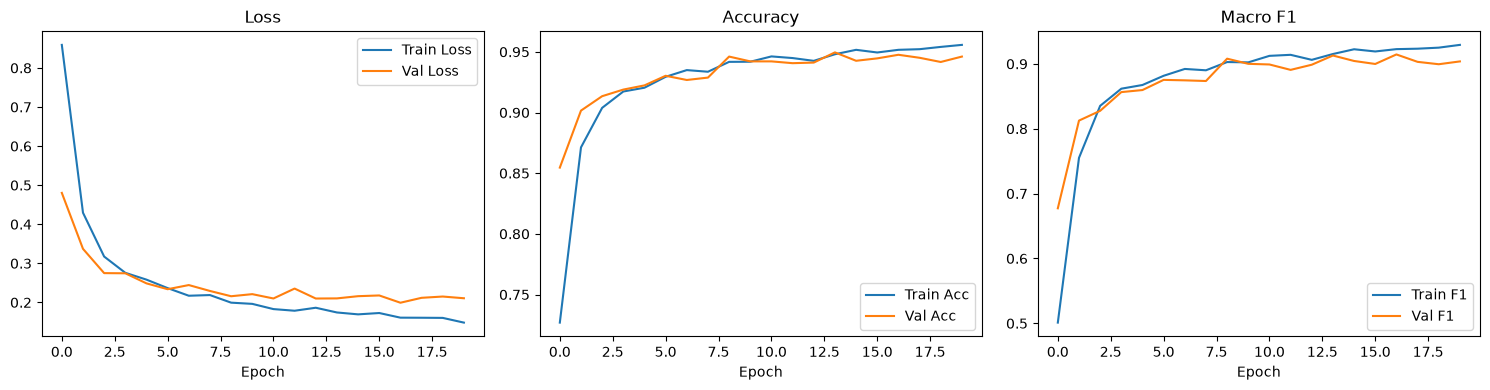

In [40]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_f1"], label="Train F1")
plt.plot(history["val_f1"], label="Val F1")
plt.title("Macro F1")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


In [41]:
best_model = IMUCNN(num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
    best_model, test_loader, criterion, DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")


Test Loss: 0.1118
Test Accuracy: 0.9697
Test Macro F1: 0.9437


In [42]:
target_names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=target_names,
    digits=4
))


                         precision    recall  f1-score   support

               Standing     0.9643    0.9643    0.9643       140
Walking (without crate)     0.9709    0.9919    0.9813       740
                Bending     0.9380    0.8963    0.9167       135
          Lifting crate     0.9590    0.9122    0.9350       205
   Walking (with crate)     0.9797    0.9891    0.9844       732
          Placing crate     0.9412    0.8276    0.8807        58

               accuracy                         0.9697      2010
              macro avg     0.9588    0.9302    0.9437      2010
           weighted avg     0.9694    0.9697    0.9693      2010



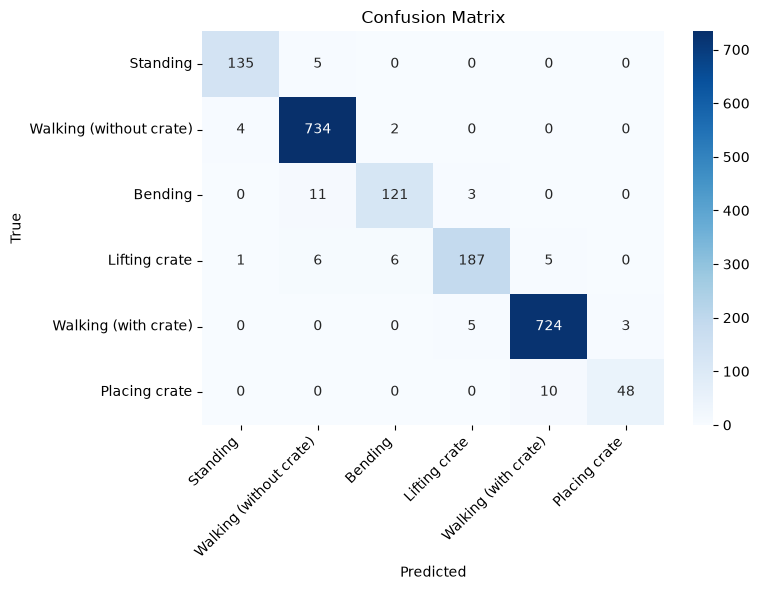

In [43]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [44]:
for i in range(min(10, len(y_true))):
    print(
        f"Sample {i}: "
        f"True = {CLASS_NAMES[int(y_true[i])]}, "
        f"Pred = {CLASS_NAMES[int(y_pred[i])]}"
    )


Sample 0: True = Standing, Pred = Walking (without crate)
Sample 1: True = Walking (without crate), Pred = Walking (without crate)
Sample 2: True = Walking (without crate), Pred = Walking (without crate)
Sample 3: True = Walking (without crate), Pred = Walking (without crate)
Sample 4: True = Lifting crate, Pred = Lifting crate
Sample 5: True = Lifting crate, Pred = Lifting crate
Sample 6: True = Lifting crate, Pred = Lifting crate
Sample 7: True = Walking (with crate), Pred = Walking (with crate)
Sample 8: True = Walking (with crate), Pred = Walking (with crate)
Sample 9: True = Walking (with crate), Pred = Walking (with crate)


In [45]:
import numpy as np
import torch

# Assuming `model` is your trained IMUCNN instance and `train_mean`, `train_std` are computed
model.eval()

def fmt_arr(arr):
    """Formats numpy array into C++ array initializer."""
    if arr.ndim == 1:
        return "{ " + ", ".join(f"(data_t){v:.8f}" for v in arr) + " }"
    elif arr.ndim == 2:
        rows = [fmt_arr(row) for row in arr]
        return "{\n  " + ",\n  ".join(rows) + "\n}"
    elif arr.ndim == 3:
        mats = [fmt_arr(mat) for mat in arr]
        return "{\n" + ",\n".join(mats) + "\n}"

def get_bn_inv_std(bn_layer):
    # inv_std = 1 / sqrt(running_var + eps)
    var = bn_layer.running_var.detach().cpu().numpy()
    eps = bn_layer.eps
    return 1.0 / np.sqrt(var + eps)

cpp_code = f"""#include "cnn_params.hpp"

// Input Normalization
const data_t input_mean[9] = {fmt_arr(train_mean.squeeze())};
const data_t input_inv_std[9] = {fmt_arr((1.0 / train_std).squeeze())};

// Conv1 + BN1
const data_t conv1_weight[32][9][5] = {fmt_arr(model.features[0].weight.detach().cpu().numpy())};
const data_t conv1_bias[32] = {fmt_arr(model.features[0].bias.detach().cpu().numpy())};
const data_t bn1_gamma[32] = {fmt_arr(model.features[1].weight.detach().cpu().numpy())};
const data_t bn1_beta[32] = {fmt_arr(model.features[1].bias.detach().cpu().numpy())};
const data_t bn1_mean[32] = {fmt_arr(model.features[1].running_mean.detach().cpu().numpy())};
const data_t bn1_inv_std[32] = {fmt_arr(get_bn_inv_std(model.features[1]))};

// Conv2 + BN2
const data_t conv2_weight[64][32][5] = {fmt_arr(model.features[4].weight.detach().cpu().numpy())};
const data_t conv2_bias[64] = {fmt_arr(model.features[4].bias.detach().cpu().numpy())};
const data_t bn2_gamma[64] = {fmt_arr(model.features[5].weight.detach().cpu().numpy())};
const data_t bn2_beta[64] = {fmt_arr(model.features[5].bias.detach().cpu().numpy())};
const data_t bn2_mean[64] = {fmt_arr(model.features[5].running_mean.detach().cpu().numpy())};
const data_t bn2_inv_std[64] = {fmt_arr(get_bn_inv_std(model.features[5]))};

// Conv3 + BN3
const data_t conv3_weight[128][64][3] = {fmt_arr(model.features[8].weight.detach().cpu().numpy())};
const data_t conv3_bias[128] = {fmt_arr(model.features[8].bias.detach().cpu().numpy())};
const data_t bn3_gamma[128] = {fmt_arr(model.features[9].weight.detach().cpu().numpy())};
const data_t bn3_beta[128] = {fmt_arr(model.features[9].bias.detach().cpu().numpy())};
const data_t bn3_mean[128] = {fmt_arr(model.features[9].running_mean.detach().cpu().numpy())};
const data_t bn3_inv_std[128] = {fmt_arr(get_bn_inv_std(model.features[9]))};

// FC Classifier
const data_t fc_weight[6][128] = {fmt_arr(model.classifier[2].weight.detach().cpu().numpy())};
const data_t fc_bias[6] = {fmt_arr(model.classifier[2].bias.detach().cpu().numpy())};
"""

with open("cnn_params.cpp", "w") as f:
    f.write(cpp_code)

print("Generated cnn_params.cpp successfully!")

Generated cnn_params.cpp successfully!
